In [1]:
import pandas as pd
import requests

In [2]:
sessions=[]

for season in range(2023,2027):
    url=f"https://api.openf1.org/v1/sessions?year={season}"
    data=requests.get(url).json()

    sessions.extend(data)

df_session=pd.DataFrame(sessions)

In [3]:
df_session.head(20)

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year,is_cancelled
0,9222,Practice,Day 1,2023-02-23T07:00:00+00:00,2023-02-23T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
1,7763,Practice,Day 2,2023-02-24T07:00:00+00:00,2023-02-24T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
2,7764,Practice,Day 3,2023-02-25T07:00:00+00:00,2023-02-25T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
3,7765,Practice,Practice 1,2023-03-03T11:30:00+00:00,2023-03-03T12:30:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
4,7766,Practice,Practice 2,2023-03-03T15:00:00+00:00,2023-03-03T16:00:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
5,7767,Practice,Practice 3,2023-03-04T11:30:00+00:00,2023-03-04T12:30:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
6,7768,Qualifying,Qualifying,2023-03-04T15:00:00+00:00,2023-03-04T16:00:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
7,7953,Race,Race,2023-03-05T15:00:00+00:00,2023-03-05T17:00:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023,False
8,7772,Practice,Practice 1,2023-03-17T13:30:00+00:00,2023-03-17T14:30:00+00:00,1142,149,Jeddah,153,KSA,Saudi Arabia,Jeddah,03:00:00,2023,False
9,7773,Practice,Practice 2,2023-03-17T17:00:00+00:00,2023-03-17T18:00:00+00:00,1142,149,Jeddah,153,KSA,Saudi Arabia,Jeddah,03:00:00,2023,False


In [4]:
df_session=df_session[df_session["session_name"]=="Race"]
df_session=df_session[df_session["date_start"]<="2025-07-06T14:00:00+00:00"]

In [5]:
df_session["session_key"].dtype

dtype('int64')

In [6]:
session_key=df_session["session_key"]
position_arr=[]
lap_arr=[]
result_arr=[]

for session in session_key:
    # url=f"https://api.openf1.org/v1/laps?session_key={session}"
    position_data = requests.get(
        f"https://api.openf1.org/v1/position?session_key={session}"
    ).json()
    
    lap_data = requests.get(
        f"https://api.openf1.org/v1/laps?session_key={session}"
    ).json()
    
    result_data = requests.get(
        f"https://api.openf1.org/v1/session_result?session_key={session}"
    ).json()

    position_arr.extend(position_data)
    lap_arr.extend(lap_data)
    result_arr.extend(result_arr)
    

In [7]:
position_arr = [x for x in position_arr if isinstance(x, dict)]
lap_arr = [x for x in lap_arr if isinstance(x, dict)]
result_arr = [x for x in result_arr if isinstance(x, dict)]

df_pos = pd.DataFrame(position_arr)
df_laps = pd.DataFrame(lap_arr)
df_result = pd.DataFrame(result_arr)

In [8]:
df_pos.head()

,date,session_key,meeting_key,driver_number,position
0,2023-03-05T14:01:06.787000+00:00,7953,1141,1,1
1,2023-03-05T14:01:06.787000+00:00,7953,1141,11,2
2,2023-03-05T14:01:06.787000+00:00,7953,1141,16,3
3,2023-03-05T14:01:06.787000+00:00,7953,1141,55,4
4,2023-03-05T14:01:06.787000+00:00,7953,1141,14,5


In [9]:
df_laps.head()

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1141,7953,1,1,2023-03-05T15:03:38.500000+00:00,33.103,42.414,23.842,232.0,231.0,False,99.359,"[None, 2048, 2049, 2049, 2051, 2051, 2049, 204...","[2051, 2049, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2051, 2051]",252.0
1,1141,7953,11,1,2023-03-05T15:03:38.500000+00:00,34.120,43.216,24.069,230.0,237.0,False,101.405,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",252.0
2,1141,7953,16,1,2023-03-05T15:03:38.500000+00:00,33.938,42.549,24.122,226.0,250.0,False,100.609,"[None, 2048, 2049, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0
3,1141,7953,31,1,2023-03-05T15:03:38.500000+00:00,36.463,45.213,24.698,233.0,238.0,False,106.374,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",254.0
4,1141,7953,27,1,2023-03-05T15:03:38.500000+00:00,37.038,45.924,24.741,220.0,239.0,False,107.703,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",249.0


In [10]:
df_result.head()

""


In [86]:
import requests
import pandas as pd

lap_arr = []

for year in [2023, 2024, 2025, 2026]:

    print(f"Processing {year}...")

    # Get all race sessions
    sessions = requests.get(
        f"https://api.openf1.org/v1/sessions?year={year}&session_name=Race"
    ).json()

    for session in sessions:

        session_key = session["session_key"]

        print(f"  Session {session_key}")

        laps = requests.get(
            f"https://api.openf1.org/v1/laps?session_key={session_key}"
        ).json()

        if isinstance(laps, list):
            lap_arr.extend(laps)
        else:
            print(f"Bad response for {session_key}")

df_laps = pd.DataFrame(lap_arr)

print(df_laps.shape)

Processing 2023...


TypeError: string indices must be integers, not 'str'

In [12]:
df[df["session_key"]==9987].tail(20)

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed


In [13]:
df.shape

(1058, 16)

In [14]:
import requests
import pandas as pd
import numpy as np

# ── Step 1: Fetch all lap data ────────────────────────────────────
data = requests.get("https://api.openf1.org/v1/laps?session_key=7953").json()
laps = pd.DataFrame(data)

print(laps.columns.tolist())
# Likely: driver_number, lap_number, lap_duration, 
#         duration_sector_1, duration_sector_2, duration_sector_3,
#         date_start, is_pit_out_lap, ...

# ── Step 2: Fetch driver info to map number → name ────────────────
drivers_data = requests.get(
    "https://api.openf1.org/v1/drivers?session_key=9987"
).json()
drivers_df = pd.DataFrame(drivers_data)

# Map driver_number to name and constructor
driver_map = drivers_df.set_index('driver_number')[
    ['name_acronym', 'team_name', 'team_colour']
].to_dict('index')

# ── Step 3: Clean lap durations ───────────────────────────────────
laps = laps.sort_values(['driver_number', 'lap_number'])

# Replace null/invalid lap times
# Pit laps, SC laps, first lap are often null or very slow
laps['lap_duration'] = pd.to_numeric(laps['lap_duration'], errors='coerce')

# Flag pit laps
laps['is_pit_lap'] = laps['is_pit_out_lap'].fillna(False)

# ── Step 4: Calculate cumulative race time per driver per lap ─────
# Position is determined by who has the lowest cumulative time

# For pit stops — pit time is NOT in lap_duration
# We need position data from a different source OR
# accept that cumulative time alone won't be perfect

# Clean approach: use lap_duration, fill missing with median for that lap
lap_medians = laps.groupby('lap_number')['lap_duration'].transform('median')
laps['lap_duration_clean'] = laps['lap_duration'].fillna(lap_medians)

# Cumulative time per driver
laps['cum_time'] = laps.groupby('driver_number')['lap_duration_clean'].cumsum()

# ── Step 5: Rank by cumulative time per lap = position ────────────
laps['position'] = (
    laps.groupby('lap_number')['cum_time']
        .rank(method='min', ascending=True)
        .astype(int)
)

# ── Step 6: Add driver info ───────────────────────────────────────
laps['driver'] = laps['driver_number'].map(
    lambda x: driver_map.get(x, {}).get('name_acronym', str(x))
)
laps['team'] = laps['driver_number'].map(
    lambda x: driver_map.get(x, {}).get('team_name', '')
)

# ── Step 7: Verify — check lap 1 vs last lap ─────────────────────
print("\n── Lap 1 positions ──────────────────────────────────────")
print(
    laps[laps['lap_number'] == 1]
    [['driver', 'lap_duration_clean', 'cum_time', 'position']]
    .sort_values('position')
    .head(10)
    .to_string(index=False)
)

last_lap = laps['lap_number'].max()
print(f"\n── Lap {last_lap} positions (final) ──────────────────────")
print(
    laps[laps['lap_number'] == last_lap]
    [['driver', 'lap_duration_clean', 'cum_time', 'position']]
    .sort_values('position')
    .head(10)
    .to_string(index=False)
)

['meeting_key', 'session_key', 'driver_number', 'lap_number', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed']

── Lap 1 positions ──────────────────────────────────────
driver  lap_duration_clean  cum_time  position
   VER              99.359    99.359         1
   LEC             100.609   100.609         2
    11             101.405   101.405         3
   SAI             102.030   102.030         4
   HAM             102.640   102.640         5
   RUS             103.015   103.015         6
   ALO             103.968   103.968         7
    77             104.530   104.530         8
   STR             105.015   105.015         9
   NOR             105.733   105.733        10

── Lap 57 positions (final) ──────────────────────
driver  lap_duration_clean  cum_time  position
   VER              96.373  5637.076         1
    11

In [15]:
# This gives real-time position per driver per timestamp
position_data = requests.get(
    "https://api.openf1.org/v1/position?session_key=7953"
).json()
pos_df = pd.DataFrame(position_data)

print(pos_df.columns.tolist())
print(pos_df.head())
# Returns: date, driver_number, meeting_key, position, session_key

# Get position at end of each lap by joining with lap completion times
pos_df['date'] = pd.to_datetime(pos_df['date'], utc=True)
laps['date_start'] = pd.to_datetime(laps['date_start'], utc=True)

# For each driver, each lap — find position at lap completion
def get_position_at_lap_end(driver_num, lap_end_time):
    driver_pos = pos_df[
        (pos_df['driver_number'] == driver_num) &
        (pos_df['date'] <= lap_end_time)
    ]
    if driver_pos.empty:
        return np.nan
    return driver_pos.iloc[-1]['position']

# Calculate lap end time = lap start + duration
laps['lap_end_time'] = laps['date_start'] + pd.to_timedelta(
    laps['lap_duration_clean'], unit='s'
)

# Apply — this takes a moment
laps['position_actual'] = laps.apply(
    lambda r: get_position_at_lap_end(r['driver_number'], r['lap_end_time']),
    axis=1
)

print("\nSample with actual positions:")
print(
    laps[laps['lap_number'] == 30]
    [['driver', 'lap_number', 'position', 'position_actual']]
    .sort_values('position_actual')
    .head(10)
)

['date', 'session_key', 'meeting_key', 'driver_number', 'position']
                               date  session_key  meeting_key  driver_number  \
0  2023-03-05T14:01:06.787000+00:00         7953         1141              1   
1  2023-03-05T14:01:06.787000+00:00         7953         1141             11   
2  2023-03-05T14:01:06.787000+00:00         7953         1141             16   
3  2023-03-05T14:01:06.787000+00:00         7953         1141             55   
4  2023-03-05T14:01:06.787000+00:00         7953         1141             14   

   position  
0         1  
1         2  
2         3  
3         4  
4         5  

Sample with actual positions:
    driver  lap_number  position  position_actual
563    VER          30         1                1
565     11          30         2                2
566    LEC          30         3                3
568    SAI          30         4                4
570    ALO          30         5                5
569    HAM          30         6    

In [16]:
# One row per driver per lap with position
race_laps = laps[[
    'lap_number',
    'driver_number',
    'driver',
    'team',
    'lap_duration_clean',
    'cum_time',
    'position_actual',   # use this if available
    'position',          # calculated fallback
    'is_pit_lap',
]].copy()

race_laps['position_final'] = race_laps['position_actual'].fillna(
    race_laps['position']
)

print(race_laps.head(20))
print(f"\nShape: {race_laps.shape}")
print(f"Laps: {race_laps['lap_number'].max()}")
print(f"Drivers: {race_laps['driver_number'].nunique()}")

race_laps.to_csv('race_laps_9987.csv', index=False)

     lap_number  driver_number driver             team  lap_duration_clean  \
0             1              1    VER  Red Bull Racing              99.359   
20            2              1    VER  Red Bull Racing              97.974   
40            3              1    VER  Red Bull Racing              98.006   
60            4              1    VER  Red Bull Racing              97.976   
80            5              1    VER  Red Bull Racing              98.035   
100           6              1    VER  Red Bull Racing              97.986   
120           7              1    VER  Red Bull Racing              98.021   
140           8              1    VER  Red Bull Racing              98.154   
160           9              1    VER  Red Bull Racing              98.278   
180          10              1    VER  Red Bull Racing              98.369   
200          11              1    VER  Red Bull Racing              98.483   
220          12              1    VER  Red Bull Racing          

In [17]:
race_laps.sort_values(by=["lap_number","position"])

,lap_number,driver_number,driver,team,lap_duration_clean,cum_time,position_actual,position,is_pit_lap,position_final
0,1,1,VER,Red Bull Racing,99.359,99.359,1,1,False,1
2,1,16,LEC,Ferrari,100.609,100.609,2,2,False,2
1,1,11,11,,101.405,101.405,3,3,False,3
5,1,55,SAI,Williams,102.030,102.030,4,4,False,4
13,1,44,HAM,Ferrari,102.640,102.640,5,5,False,5
...,...,...,...,...,...,...,...,...,...,...
1053,57,63,RUS,Mercedes,97.767,5692.962,7,7,False,7
1054,57,77,77,,98.407,5709.759,8,8,False,8
1055,57,10,GAS,Alpine,98.147,5710.870,9,9,False,9
1056,57,23,ALB,Williams,98.137,5726.869,10,10,False,10


In [18]:
race_laps[race_laps["lap_number"]==50]

,lap_number,driver_number,driver,team,lap_duration_clean,cum_time,position_actual,position,is_pit_lap,position_final
925,50,1,VER,Red Bull Racing,97.250,4959.262,1,1,False,1
940,50,2,2,,97.290,5049.673,12,12,False,12
954,50,4,NOR,McLaren,95.257,5130.631,17,17,False,17
936,50,10,GAS,Alpine,96.551,5029.592,9,9,False,9
928,50,11,11,,97.731,4970.098,2,2,False,2
930,50,14,ALO,Aston Martin,96.331,4994.597,3,3,False,3
933,50,18,STR,Aston Martin,97.388,5006.360,6,6,False,6
944,50,20,20,,98.315,5062.856,15,15,False,15
943,50,21,21,,99.089,5062.403,14,14,False,14
939,50,22,TSU,Red Bull Racing,97.624,5042.971,11,11,False,11


In [19]:
race_laps[race_laps["position"]!=race_laps["position_final"]].sort_values(by="lap_number")

,lap_number,driver_number,driver,team,lap_duration_clean,cum_time,position_actual,position,is_pit_lap,position_final
211,11,2,2,,101.5320,1115.6100,12,11,False,12
247,13,18,STR,Aston Martin,101.1200,1306.2610,7,6,False,7
277,14,21,21,,98.8290,1444.7060,17,18,False,17
276,14,4,NOR,McLaren,99.2430,1443.5280,16,17,False,16
278,14,27,HUL,Kick Sauber,98.8470,1445.8010,18,19,False,18
275,14,81,PIA,McLaren,98.8590,1441.7130,20,16,False,20
279,14,24,24,,99.3300,1446.3020,19,20,False,19
557,29,20,20,,101.9790,2944.6090,12,13,False,12
558,29,23,ALB,Williams,98.1270,2944.6000,13,12,False,13
768,40,21,21,,113.5440,4053.2100,13,14,False,13


In [20]:
df.head()

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1141,7953,1,1,2023-03-05T15:03:38.500000+00:00,33.103,42.414,23.842,232.0,231.0,False,99.359,"[None, 2048, 2049, 2049, 2051, 2051, 2049, 204...","[2051, 2049, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2051, 2051]",252.0
1,1141,7953,11,1,2023-03-05T15:03:38.500000+00:00,34.120,43.216,24.069,230.0,237.0,False,101.405,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",252.0
2,1141,7953,16,1,2023-03-05T15:03:38.500000+00:00,33.938,42.549,24.122,226.0,250.0,False,100.609,"[None, 2048, 2049, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0
3,1141,7953,31,1,2023-03-05T15:03:38.500000+00:00,36.463,45.213,24.698,233.0,238.0,False,106.374,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",254.0
4,1141,7953,27,1,2023-03-05T15:03:38.500000+00:00,37.038,45.924,24.741,220.0,239.0,False,107.703,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",249.0


In [21]:
df['position'] = df.groupby(['session_key','lap_number']).cumcount() + 1

In [22]:
df.head(25)

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,position
0,1141,7953,1,1,2023-03-05T15:03:38.500000+00:00,33.103,42.414,23.842,232.0,231.0,False,99.359,"[None, 2048, 2049, 2049, 2051, 2051, 2049, 204...","[2051, 2049, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2051, 2051]",252.0,1
1,1141,7953,11,1,2023-03-05T15:03:38.500000+00:00,34.120,43.216,24.069,230.0,237.0,False,101.405,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",252.0,2
2,1141,7953,16,1,2023-03-05T15:03:38.500000+00:00,33.938,42.549,24.122,226.0,250.0,False,100.609,"[None, 2048, 2049, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0,3
3,1141,7953,31,1,2023-03-05T15:03:38.500000+00:00,36.463,45.213,24.698,233.0,238.0,False,106.374,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",254.0,4
4,1141,7953,27,1,2023-03-05T15:03:38.500000+00:00,37.038,45.924,24.741,220.0,239.0,False,107.703,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",249.0,5
5,1141,7953,55,1,2023-03-05T15:03:38.500000+00:00,34.431,43.409,24.190,225.0,240.0,False,102.030,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",235.0,6
6,1141,7953,4,1,2023-03-05T15:03:38.500000+00:00,36.383,44.789,24.561,229.0,236.0,False,105.733,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 0]",263.0,7
7,1141,7953,77,1,2023-03-05T15:03:38.500000+00:00,36.200,43.757,24.573,230.0,251.0,False,104.530,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",266.0,8
8,1141,7953,14,1,2023-03-05T15:03:38.500000+00:00,35.523,43.884,24.561,222.0,247.0,False,103.968,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0,9
9,1141,7953,24,1,2023-03-05T15:03:38.500000+00:00,38.025,45.972,24.736,223.0,241.0,False,108.733,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",246.0,10


In [23]:
final_position = (
    df.groupby('driver_number')['position']
      .last()
)

In [24]:
final_position.head(20)

driver_number
1      1
2     12
4     17
10     9
11     2
14     3
16     3
18     6
20    13
21    14
22    11
23    10
24    16
27    15
31    17
44     5
55     4
63     7
77     8
81    16
Name: position, dtype: int64

In [25]:
df['final_position'] = df['driver_number'].map(final_position)

In [26]:
df['total_laps'] = df.groupby('session_key')['lap_number'].transform('max')

df['lap_remaining'] = df['total_laps'] - df['lap_number'] + 1

In [27]:
df.head()

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,position,final_position,total_laps,lap_remaining
0,1141,7953,1,1,2023-03-05T15:03:38.500000+00:00,33.103,42.414,23.842,232.0,231.0,False,99.359,"[None, 2048, 2049, 2049, 2051, 2051, 2049, 204...","[2051, 2049, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2051, 2051]",252.0,1,1,57,57
1,1141,7953,11,1,2023-03-05T15:03:38.500000+00:00,34.120,43.216,24.069,230.0,237.0,False,101.405,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",252.0,2,2,57,57
2,1141,7953,16,1,2023-03-05T15:03:38.500000+00:00,33.938,42.549,24.122,226.0,250.0,False,100.609,"[None, 2048, 2049, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0,3,3,57,57
3,1141,7953,31,1,2023-03-05T15:03:38.500000+00:00,36.463,45.213,24.698,233.0,238.0,False,106.374,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",254.0,4,17,57,57
4,1141,7953,27,1,2023-03-05T15:03:38.500000+00:00,37.038,45.924,24.741,220.0,239.0,False,107.703,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",249.0,5,15,57,57


In [28]:
df_train=pd.read_csv("train.csv")

In [29]:
df_train[df_train["race_date"]=='2023-03-05']

,Unnamed: 0,season,round,race_name,race_date,driver_number,driver_id,driver,constructor,grid,...,avg_circuit_points,QualiToRace,dnf,dnf_last5,positions_gained,circuit_avg_positions_gained,avg_quali_season,won,avg_posi_season,QualiToPos
2060,60,2023,1,Bahrain Grand Prix,2023-03-05,23,albon,Alexander Albon,Williams,15,...,3.600000,1.500000,0,1.0,5,0.064286,15.0,0,10.0,1.500000
2082,171,2023,1,Bahrain Grand Prix,2023-03-05,14,alonso,Fernando Alonso,Aston Martin,5,...,5.000000,1.666667,0,2.0,2,0.064286,5.0,0,3.0,1.666667
2104,323,2023,1,Bahrain Grand Prix,2023-03-05,77,bottas,Valtteri Bottas,Alfa Romeo,12,...,9.714286,1.500000,0,1.0,4,0.064286,12.0,0,8.0,1.500000
2126,400,2023,1,Bahrain Grand Prix,2023-03-05,21,de_vries,Nyck de Vries,AlphaTauri,19,...,0.000000,1.357143,0,0.0,5,0.064286,19.0,0,14.0,1.357143
2136,535,2023,1,Bahrain Grand Prix,2023-03-05,10,gasly,Pierre Gasly,Alpine F1 Team,20,...,3.714286,2.222222,0,0.0,11,0.064286,20.0,0,9.0,2.222222
2158,800,2023,1,Bahrain Grand Prix,2023-03-05,44,hamilton,Lewis Hamilton,Mercedes,7,...,17.285714,1.400000,0,1.0,2,0.064286,7.0,0,5.0,1.400000
2180,893,2023,1,Bahrain Grand Prix,2023-03-05,27,hulkenberg,Nico Hülkenberg,Haas F1 Team,10,...,1.600000,0.666667,0,1.0,-5,0.064286,10.0,0,15.0,0.666667
2202,1020,2023,1,Bahrain Grand Prix,2023-03-05,20,kevin_magnussen,Kevin Magnussen,Haas F1 Team,17,...,3.333333,1.307692,0,1.0,4,0.064286,17.0,0,13.0,1.307692
2229,1300,2023,1,Bahrain Grand Prix,2023-03-05,16,leclerc,Charles Leclerc,Ferrari,3,...,9.000000,0.157895,1,0.0,-16,0.064286,3.0,0,19.0,0.157895
2251,1449,2023,1,Bahrain Grand Prix,2023-03-05,1,max_verstappen,Max Verstappen,Red Bull,1,...,14.285714,1.000000,0,0.0,0,0.064286,1.0,1,1.0,1.000000


In [44]:
df.head()

,meeting_key,session_key,driver_number,lap_number,race_date,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,position,final_position,total_laps,lap_remaining
0,1141,7953,1,1,2023-03-05T15:03:38.500000+00:00,33.103,42.414,23.842,232.0,231.0,False,99.359,"[None, 2048, 2049, 2049, 2051, 2051, 2049, 204...","[2051, 2049, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2051, 2051]",252.0,1,1,57,57
1,1141,7953,11,1,2023-03-05T15:03:38.500000+00:00,34.120,43.216,24.069,230.0,237.0,False,101.405,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",252.0,2,2,57,57
2,1141,7953,16,1,2023-03-05T15:03:38.500000+00:00,33.938,42.549,24.122,226.0,250.0,False,100.609,"[None, 2048, 2049, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0,3,3,57,57
3,1141,7953,31,1,2023-03-05T15:03:38.500000+00:00,36.463,45.213,24.698,233.0,238.0,False,106.374,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",254.0,4,17,57,57
4,1141,7953,27,1,2023-03-05T15:03:38.500000+00:00,37.038,45.924,24.741,220.0,239.0,False,107.703,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",249.0,5,15,57,57


In [43]:
df.rename(columns={"date_start": "race_date"}, inplace=True)

In [55]:
df["race_date"] = pd.to_datetime(df["race_date"], utc=True).dt.normalize()
df_train["race_date"] = pd.to_datetime(df_train["race_date"], utc=True).dt.normalize()

In [56]:
df["race_date"].dtype

datetime64[ns, UTC]

In [57]:
df.head()

,meeting_key,session_key,driver_number,lap_number,race_date,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,position,final_position,total_laps,lap_remaining
0,1141,7953,1,1,2023-03-05 00:00:00+00:00,33.103,42.414,23.842,232.0,231.0,False,99.359,"[None, 2048, 2049, 2049, 2051, 2051, 2049, 204...","[2051, 2049, 2051, 2049, 2051, 2049, 2049, 204...","[2051, 2049, 2049, 2049, 2051, 2051]",252.0,1,1,57,57
1,1141,7953,11,1,2023-03-05 00:00:00+00:00,34.120,43.216,24.069,230.0,237.0,False,101.405,"[None, 2048, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049]",252.0,2,2,57,57
2,1141,7953,16,1,2023-03-05 00:00:00+00:00,33.938,42.549,24.122,226.0,250.0,False,100.609,"[None, 2048, 2049, 2051, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 205...","[2049, 2049, 2049, 2049, 2049, 2049]",255.0,3,3,57,57
3,1141,7953,31,1,2023-03-05 00:00:00+00:00,36.463,45.213,24.698,233.0,238.0,False,106.374,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049]",254.0,4,17,57,57
4,1141,7953,27,1,2023-03-05 00:00:00+00:00,37.038,45.924,24.741,220.0,239.0,False,107.703,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2048]",249.0,5,15,57,57


In [58]:
df_temp = df.merge(
    df_train[
        [
            'race_date',
            'season',
            'round',
            'driver',
            'driver_number',
            'constructor',
            'grid',
            'position',
            'avg_circuit_points',
            'constructor_pts_per_race',
            'dnf_last5'
        ]
    ].rename(columns={"position": "Position_Res"}),
    on=["race_date", "driver_number"],
    how="left"
)

In [59]:
df_temp.sort_values(by='race_date')

,meeting_key,session_key,driver_number,lap_number,race_date,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,...,lap_remaining,season,round,driver,constructor,grid,Position_Res,avg_circuit_points,constructor_pts_per_race,dnf_last5
0,1141,7953,1,1,2023-03-05 00:00:00+00:00,33.103,42.414,23.842,232.0,231.0,...,57,2023,1,Max Verstappen,Red Bull,1,1,14.285714,0.0,0.0
696,1141,7953,27,36,2023-03-05 00:00:00+00:00,31.451,42.707,24.087,231.0,248.0,...,22,2023,1,Nico Hülkenberg,Haas F1 Team,10,15,1.600000,0.0,1.0
697,1141,7953,4,36,2023-03-05 00:00:00+00:00,32.216,43.423,24.247,141.0,256.0,...,22,2023,1,Lando Norris,McLaren,11,17,6.666667,0.0,1.0
698,1141,7953,11,37,2023-03-05 00:00:00+00:00,30.919,41.914,23.511,NaN,239.0,...,21,2023,1,Sergio Pérez,Red Bull,2,2,6.714286,0.0,0.0
699,1141,7953,16,37,2023-03-05 00:00:00+00:00,NaN,42.385,23.715,NaN,251.0,...,21,2023,1,Charles Leclerc,Ferrari,3,19,9.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,1141,7953,55,19,2023-03-05 00:00:00+00:00,31.208,42.939,24.063,227.0,243.0,...,39,2023,1,Carlos Sainz,Ferrari,4,4,8.428571,0.0,2.0
360,1141,7953,44,19,2023-03-05 00:00:00+00:00,31.294,43.297,24.093,NaN,238.0,...,39,2023,1,Lewis Hamilton,Mercedes,7,5,17.285714,0.0,1.0
361,1141,7953,14,19,2023-03-05 00:00:00+00:00,31.313,42.965,24.083,228.0,245.0,...,39,2023,1,Fernando Alonso,Aston Martin,5,3,5.000000,0.0,2.0
347,1141,7953,22,18,2023-03-05 00:00:00+00:00,31.402,43.402,24.498,229.0,237.0,...,40,2023,1,Yuki Tsunoda,AlphaTauri,14,11,1.500000,0.0,1.0


In [60]:
print(type(df["race_date"].iloc[0]))
print(type(df_train["race_date"].iloc[0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [61]:
df_temp.to_csv('driver_lap.csv')

In [66]:
df_temp.columns

Index(['meeting_key', 'session_key', 'driver_number', 'lap_number',
       'race_date', 'duration_sector_1', 'duration_sector_2',
       'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap',
       'lap_duration', 'segments_sector_1', 'segments_sector_2',
       'segments_sector_3', 'st_speed', 'position', 'final_position',
       'total_laps', 'lap_remaining', 'season', 'round', 'driver',
       'constructor', 'grid', 'Position_Res', 'avg_circuit_points',
       'constructor_pts_per_race', 'dnf_last5'],
      dtype='object')

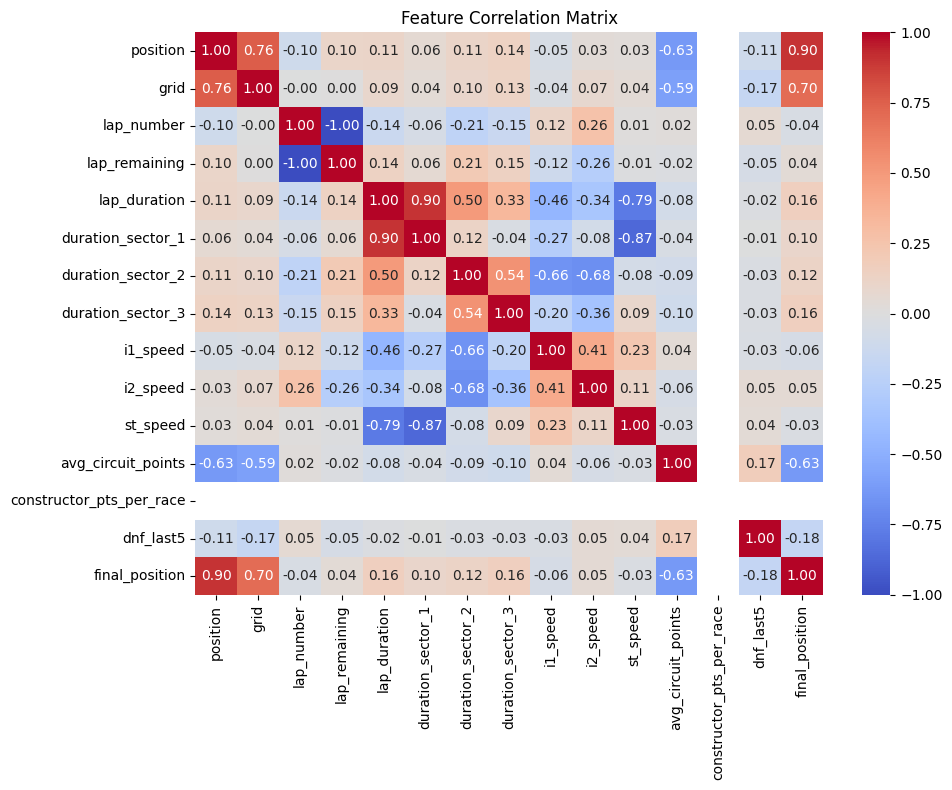

In [68]:
features = [
    "position",                  
    "grid",
    "lap_number",
    "lap_remaining",
    "lap_duration",
    "duration_sector_1",
    "duration_sector_2",
    "duration_sector_3",
    "i1_speed",
    "i2_speed",
    "st_speed",
    "avg_circuit_points",
    "constructor_pts_per_race",
    "dnf_last5",
    "final_position"
]

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_temp[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [75]:
df_temp["positions_to_gain"] = df_temp["position"] - 1

df_temp["gain_per_lap"] = df_temp["positions_to_gain"] / df_temp["lap_remaining"]

In [76]:
df_temp.head()

,meeting_key,session_key,driver_number,lap_number,race_date,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,...,round,driver,constructor,grid,Position_Res,avg_circuit_points,constructor_pts_per_race,dnf_last5,positions_to_gain,gain_per_lap
0,1141,7953,1,1,2023-03-05 00:00:00+00:00,33.103,42.414,23.842,232.0,231.0,...,1,Max Verstappen,Red Bull,1,1,14.285714,0.0,0.0,0,0.000000
1,1141,7953,11,1,2023-03-05 00:00:00+00:00,34.120,43.216,24.069,230.0,237.0,...,1,Sergio Pérez,Red Bull,2,2,6.714286,0.0,0.0,1,0.017544
2,1141,7953,16,1,2023-03-05 00:00:00+00:00,33.938,42.549,24.122,226.0,250.0,...,1,Charles Leclerc,Ferrari,3,19,9.000000,0.0,0.0,2,0.035088
3,1141,7953,31,1,2023-03-05 00:00:00+00:00,36.463,45.213,24.698,233.0,238.0,...,1,Esteban Ocon,Alpine F1 Team,9,18,1.500000,0.0,0.0,3,0.052632
4,1141,7953,27,1,2023-03-05 00:00:00+00:00,37.038,45.924,24.741,220.0,239.0,...,1,Nico Hülkenberg,Haas F1 Team,10,15,1.600000,0.0,1.0,4,0.070175


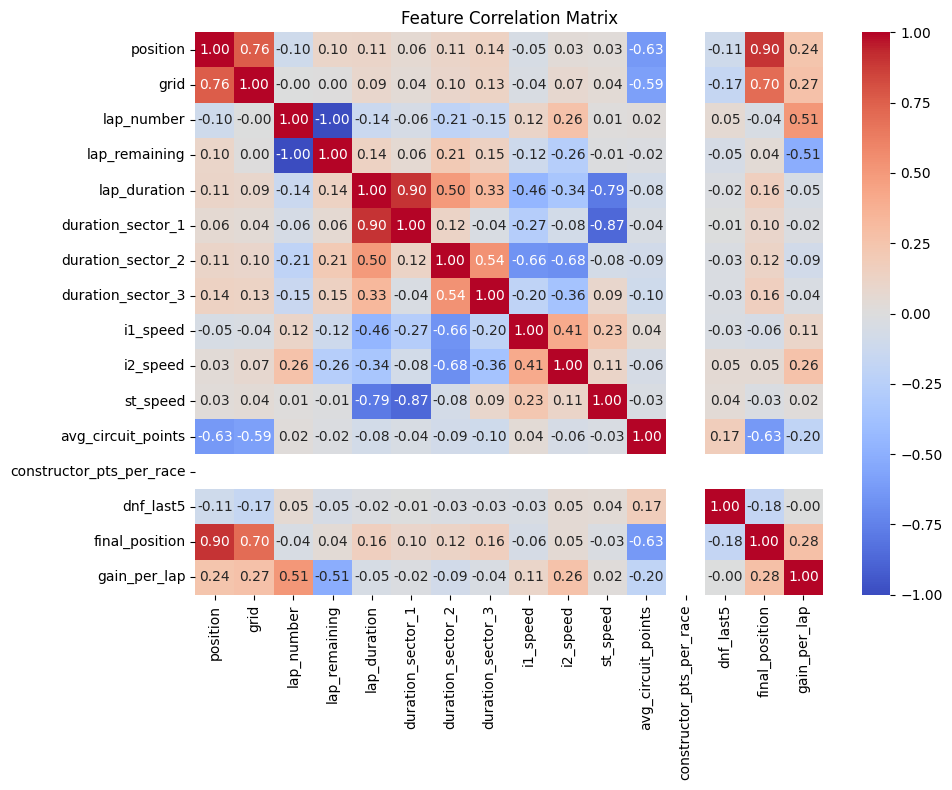

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_temp[features + ["gain_per_lap"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [79]:
df_temp = df_temp[df_temp["lap_number"] % 5 == 0]

In [82]:
import xgboost as xgb
import pandas as pd
from sklearn.metrics import roc_auc_score

LIVE_FEATURES = [
    "position",                  # Current position
    "grid",
    "lap_remaining",
    "gain_per_lap",
    "lap_duration",
    "avg_circuit_points",
    "constructor_pts_per_race",
    "dnf_last5",
]

# ----------------------------
# Target
# ----------------------------
df_temp["won"] = (df_temp["final_position"] == 1).astype(int)

# ----------------------------
# Handle missing values
# ----------------------------
for col in LIVE_FEATURES:
    if df_temp[col].dtype.kind in "if":
        df_temp[col] = df_temp[col].fillna(df_temp[col].median())
    else:
        df_temp[col] = df_temp[col].fillna(0)

# ----------------------------
# Time-based split
# ----------------------------
train = df_temp[df_temp["season"] <= 2023]
val   = df_temp[df_temp["season"] == 2024]
test  = df_temp[df_temp["season"] == 2025]

X_train = train[LIVE_FEATURES]
y_train = train["won"]

X_val = val[LIVE_FEATURES]
y_val = val["won"]

X_test = test[LIVE_FEATURES]
y_test = test["won"]

# ----------------------------
# Model
# ----------------------------
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=19,
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# ----------------------------
# Prediction
# ----------------------------
test = test.copy()
test["pred_prob"] = model.predict_proba(X_test)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
auc = roc_auc_score(y_test, test["pred_prob"])
print(f"ROC-AUC: {auc:.4f}")

def top_n_accuracy(group, n):
    ranked = group.nlargest(n, "pred_prob")
    return int(ranked["won"].any())

for n in [1, 3, 5]:
    acc = (
        test.groupby(["season", "round"])
        .apply(top_n_accuracy, n=n)
        .mean()
    )
    print(f"Top-{n} Accuracy: {acc:.2%}")

# ----------------------------
# Feature Importance
# ----------------------------
importance = (
    pd.Series(
        model.feature_importances_,
        index=LIVE_FEATURES
    )
    .sort_values(ascending=False)
)

print("\nFeature Importance")
print(importance)

[0]	validation_0-logloss:0.00000
[30]	validation_0-logloss:0.00000


C:\Users\dpsvn\AppData\Local\Temp\ipykernel_7912\515956984.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp["won"] = (df_temp["final_position"] == 1).astype(int)
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_7912\515956984.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp[col] = df_temp[col].fillna(df_temp[col].median())
C:\Users\dpsvn\AppData\Local\Temp\ipykernel_7912\515956984.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [83]:
print(df_temp["season"].value_counts().sort_index())

season
2023    205
Name: count, dtype: int64


In [84]:
df.to_csv('check.csv')